ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

**Dataset used in this version:** `index_1.csv` (coffee sales transactions).

![step1.png](attachment:step1.png)

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

## Loading data in different ways
### Option 1: Load local CSV

In [2]:
# Load Dataset

df = pd.read_csv("index_1.csv")

# Display first 5 rows
df.head(7)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate


The dataset consists of individual **coffee sales** records, where each row represents a single transaction.

**Columns overview:**
- `date`: transaction date (YYYY-MM-DD)
- `datetime`: full timestamp
- `cash_type`: payment type (e.g., cash/card)
- `card`: anonymized card identifier
- `money`: transaction amount
- `coffee_name`: coffee item name

From the first few rows, we can observe a mix of datetime and categorical fields, plus a numeric amount column.
This means we should verify data types, handle missing values, and explore patterns across time, coffee types, and payment methods.

### Option 2: Load online dataset using tensorflow.keras.datasets

In [3]:
from tensorflow.keras import datasets
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


This example demonstrates how datasets can be loaded directly from online sources using built-in libraries. The CIFAR-10 dataset is downloaded automatically and provided in predefined training and testing sets. This approach is commonly used in supervised learning experiments, especially for image-based datasets, as it simplifies data access and preparation.

### Option 3: Kaggle-style path reading

In [4]:
# train_df = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/train.csv")
# test_df  = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/test.csv")

# train_df.head()

### Data type of columns

In [5]:
# viewing the data types of columns
df.dtypes

,0
date,object
datetime,object
cash_type,object
card,object
money,float64
coffee_name,object


The data type inspection shows that several columns are stored as object types, including date and monetary values. While categorical features are expected to be objects, date and numerical values stored as objects indicate formatting issues. Identifying such inconsistencies is important before proceeding with deeper analysis.

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Ensure money is numeric
df['money'] = pd.to_numeric(df['money'], errors='coerce')

df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


The date column has been converted to a datetime format, and the revenue column has been cleaned and converted to a numerical data type. This ensures that time-based analysis and numerical calculations can be performed correctly. Correcting data types at this stage improves the reliability of subsequent analysis.

### Check Missing Values

In [7]:
print(df.isna().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


The missing values analysis shows whether any features contain null or undefined values.
If missing values are present, they can affect summary statistics and machine learning models.
In this dataset, the presence or absence of missing values helps determine whether data cleaning steps, such as imputation or row removal, will be required in later preprocessing stages.

### Check duplicate rows

In [8]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


The duplicate records check identifies whether the same sales transaction appears more than once in the dataset.
Duplicate entries can bias the analysis by overrepresenting certain transactions or categories.
If duplicates exist, they should be investigated to determine whether they represent valid repeated transactions or data entry errors.

### No. of rows and columns

In [9]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3636, 6) 

number of rows:  3636
number of columns:  6


The dataset consists of 3,636 rows and 6 columns. This size is suitable for exploratory analysis and allows meaningful insights without being computationally expensive. Knowing the dataset dimensions helps in selecting appropriate analysis and visualization techniques.

### Descriptive summary Statistics

In [10]:
# Statistical summary
df.describe(include='all')

,date,datetime,cash_type,card,money,coffee_name
count,3636,3636,3636,3547,3636.000000,3636
unique,NaN,NaN,2,1316,NaN,8
top,NaN,NaN,card,ANON-0000-0000-0012,NaN,Americano with Milk
freq,NaN,NaN,3547,129,NaN,824
mean,2024-09-30 11:56:02.376237568,2024-10-01 02:35:30.535053568,NaN,NaN,31.746859,NaN
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,NaN,NaN,18.120000,NaN
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750080,NaN,NaN,27.920000,NaN
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500160,NaN,NaN,32.820000,NaN
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750144,NaN,NaN,35.760000,NaN
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,NaN,NaN,40.000000,NaN


The descriptive statistics provide an overview of both numerical and categorical features. Numerical summaries reveal the central tendency, spread, and range of values, while categorical summaries show the number of unique categories and their frequencies. This confirms that the dataset contains a limited number of numerical features and several categorical features, making it descriptive in nature.

### Univariate Analysis

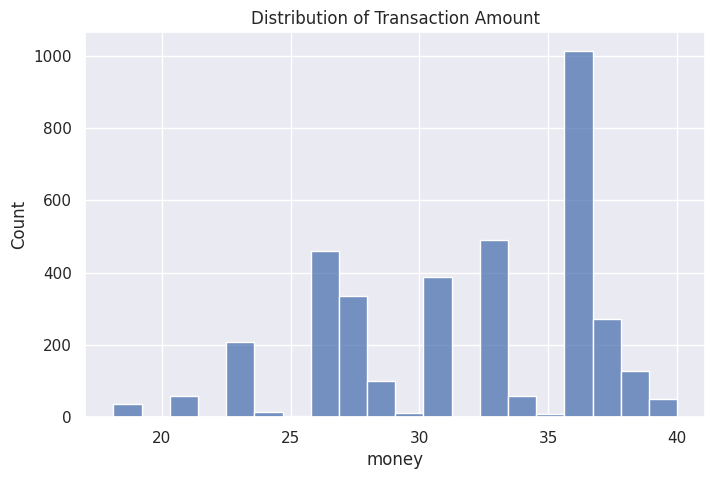

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['money'], bins=20)
plt.title("Distribution of Transaction Amount")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

The distribution of boxes shipped is right-skewed, indicating that most transactions involve a relatively small number of boxes, while a few transactions involve much larger shipments. Such skewness is common in sales data and may influence later modeling decisions.

### Distribution of Sales money

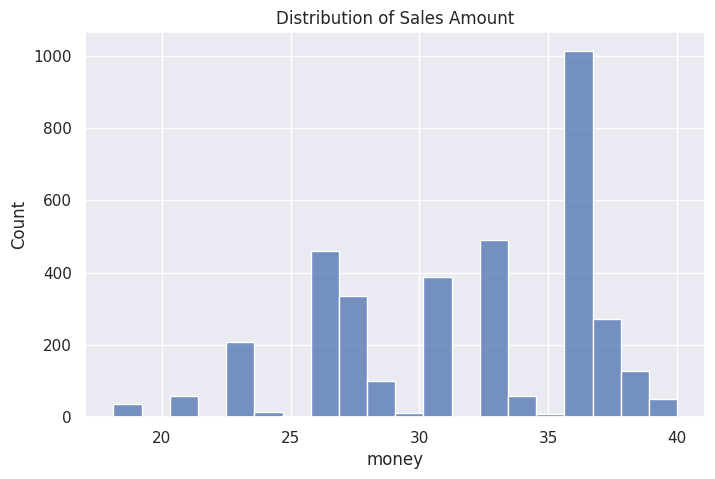

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['money'], bins=20)
plt.title("Distribution of Sales Amount")
plt.show()

The revenue distribution is also right-skewed, with most transactions generating moderate revenue and fewer transactions generating very high revenue. This suggests the presence of high-value sales that may act as outliers or important contributors to total revenue.

## Bivariate Analysis

### Sales money by Payment Type

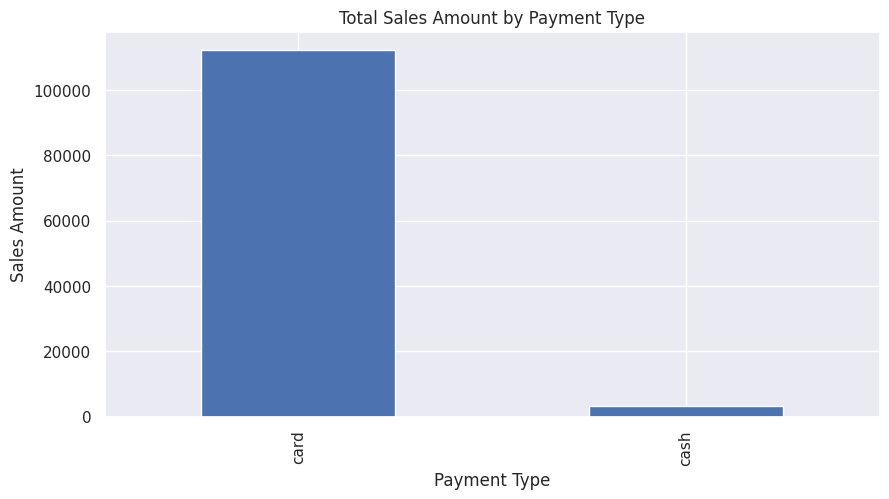

In [13]:
payment_revenue = df.groupby('cash_type')['money'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
payment_revenue.plot(kind='bar')
plt.title('Total Sales Amount by Payment Type')
plt.ylabel('Sales Amount')
plt.xlabel('Payment Type')
plt.show()

The total revenue varies across countries, with some countries contributing significantly more to overall sales than others. This indicates geographical differences in sales performance and suggests that country is an important categorical feature in the dataset.

### Sales money by Coffee

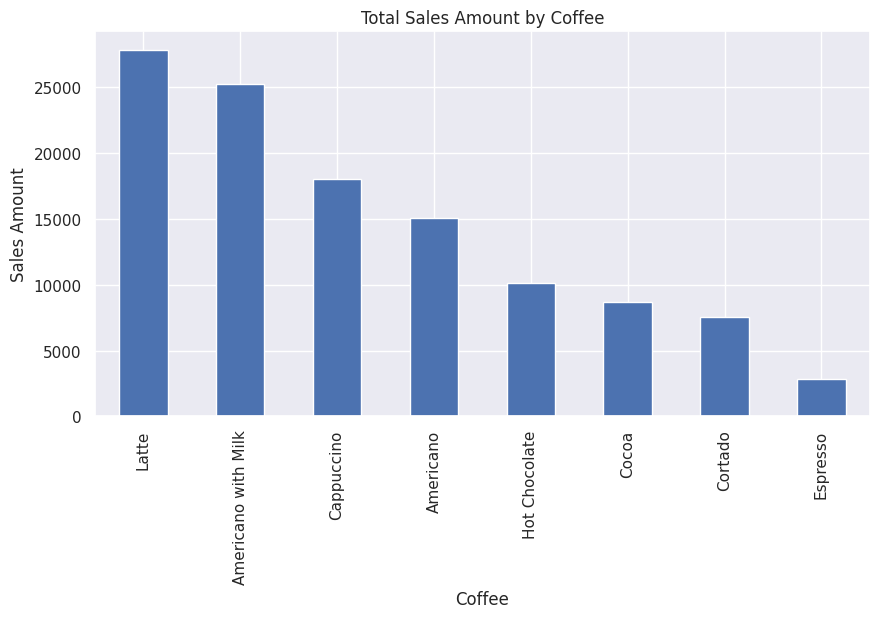

In [14]:
coffee_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
coffee_revenue.plot(kind='bar')
plt.title('Total Sales Amount by Coffee')
plt.ylabel('Sales Amount')
plt.xlabel('Coffee')
plt.show()

The revenue distribution across products shows that certain coffee products generate higher total revenue than others. This highlights product-level performance differences and suggests that product type plays a significant role in revenue generation.

### Sales money by Card ID

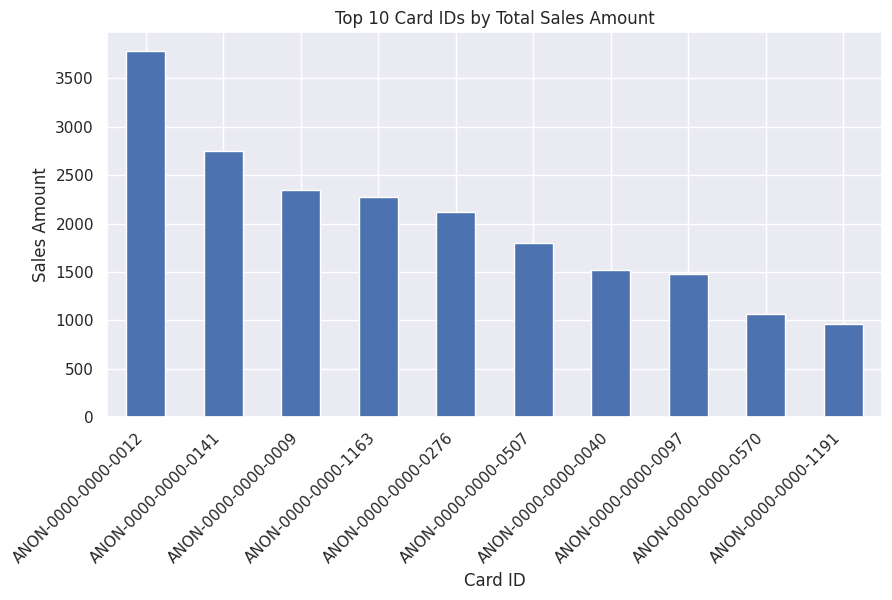

In [15]:
card_revenue = df.groupby('card')['money'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
card_revenue.plot(kind='bar')
plt.title('Top 10 Card IDs by Total Sales Amount')
plt.ylabel('Sales Amount')
plt.xlabel('Card ID')
plt.xticks(rotation=45, ha='right')
plt.show()

The revenue contribution varies among salespersons, with a few individuals generating higher total revenue. This may reflect differences in sales regions, experience, or customer base, and indicates that the sales person feature may influence sales outcomes.

### Boxes vs Sales money Relationship

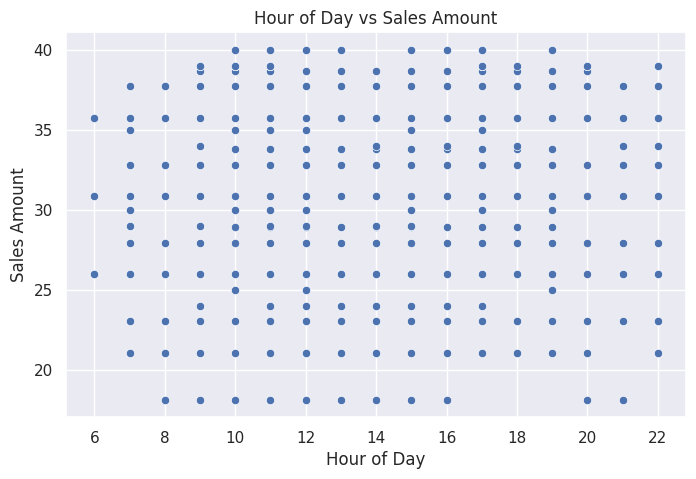

In [16]:
# Create hour feature for time-of-day analysis
df['hour'] = df['datetime'].dt.hour

plt.figure(figsize=(8,5))
sns.scatterplot(x='hour', y='money', data=df)
plt.title('Hour of Day vs Sales Amount')
plt.xlabel('Hour of Day')
plt.ylabel('Sales Amount')
plt.show()

The scatter plot shows a general positive relationship between the number of boxes shipped and revenue. However, the spread of points indicates variability, suggesting that revenue is influenced by additional factors beyond shipment volume, such as product type or pricing.

### Correlation Matrix

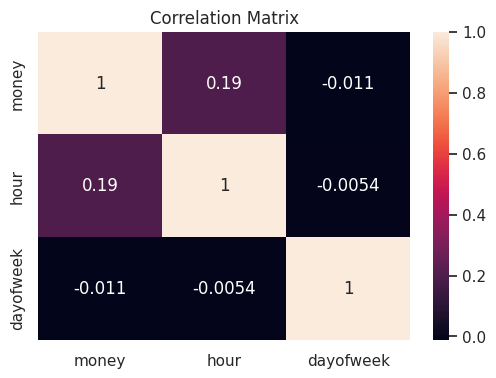

In [17]:
# Correlation on numeric engineered features
df['dayofweek'] = df['datetime'].dt.dayofweek
df['hour'] = df['datetime'].dt.hour

plt.figure(figsize=(6,4))
sns.heatmap(df[['money','hour','dayofweek']].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

The correlation matrix shows a weak positive correlation between boxes shipped and revenue. This suggests that while shipment volume contributes to revenue, it is not the sole determining factor. Other features likely play an important role in explaining revenue variation.

## Time-Based Analysis
### Monthly Sales money Trend

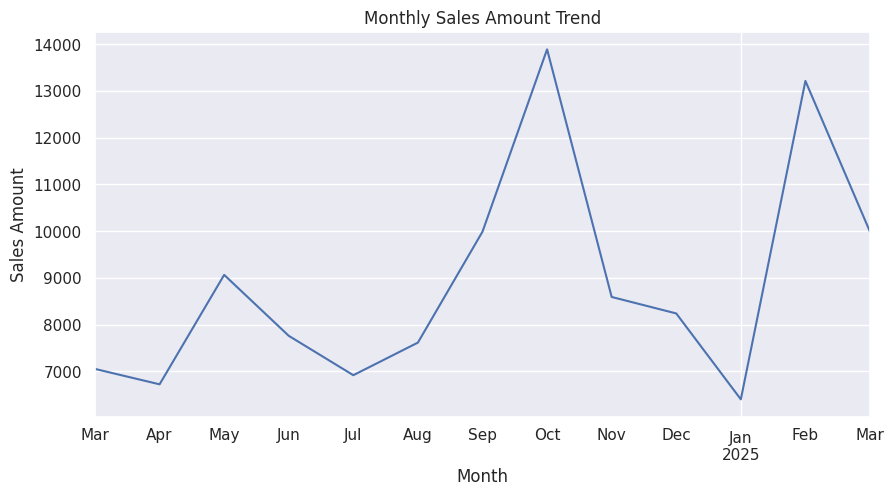

In [18]:
df['Month'] = df['datetime'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['money'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title('Monthly Sales Amount Trend')
plt.ylabel('Sales Amount')
plt.xlabel('Month')
plt.show()

The monthly revenue trend shows fluctuations over time, indicating seasonal or periodic variations in sales. Identifying such trends is useful for understanding business cycles and can inform forecasting and time-series modeling in future analysis.